# Employee Attrition Prediction
### Data Science Capstone Project
### By: Gopi

# Step 1: Data Loading and Initial Exploration
In this step, we load the dataset and perform initial inspection
to understand its structure, data types, and missing values.

In [89]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.metrics import confusion_matrix

In [90]:
# Step 2: Load dataset
df = pd.read_csv("capstone_employee_attrition_dataset.csv")

print("Shape of dataset:", df.shape)

Shape of dataset: (20000, 29)


In [91]:
print("\nColumn names:")
print(df.columns)


Column names:
Index(['employee_id', 'age', 'gender', 'marital_status', 'education',
       'education_field', 'department', 'job_role', 'job_level',
       'business_travel', 'distance_from_home_km', 'num_companies_worked',
       'years_at_company', 'years_in_current_role',
       'years_since_last_promotion', 'years_with_current_manager',
       'monthly_income_usd', 'stock_option_level', 'num_projects_last_year',
       'training_times_last_year', 'environment_satisfaction',
       'job_satisfaction', 'work_life_balance', 'job_involvement',
       'relationship_satisfaction', 'performance_rating', 'overtime',
       'attrition', 'join_date'],
      dtype='object')


In [92]:
print("\nData types:")
print(df.dtypes)


Data types:
employee_id                    int64
age                            int64
gender                        object
marital_status                object
education                      int64
education_field               object
department                    object
job_role                      object
job_level                      int64
business_travel               object
distance_from_home_km          int64
num_companies_worked           int64
years_at_company               int64
years_in_current_role          int64
years_since_last_promotion     int64
years_with_current_manager     int64
monthly_income_usd             int64
stock_option_level             int64
num_projects_last_year         int64
training_times_last_year       int64
environment_satisfaction       int64
job_satisfaction               int64
work_life_balance              int64
job_involvement                int64
relationship_satisfaction      int64
performance_rating             int64
overtime                 

In [93]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
employee_id                   0
age                           0
gender                        0
marital_status                0
education                     0
education_field               0
department                    0
job_role                      0
job_level                     0
business_travel               0
distance_from_home_km         0
num_companies_worked          0
years_at_company              0
years_in_current_role         0
years_since_last_promotion    0
years_with_current_manager    0
monthly_income_usd            0
stock_option_level            0
num_projects_last_year        0
training_times_last_year      0
environment_satisfaction      0
job_satisfaction              0
work_life_balance             0
job_involvement               0
relationship_satisfaction     0
performance_rating            0
overtime                      0
attrition                     0
join_date                     0
dtype: int64


In [94]:
print("\nFirst 5 rows:")
print(df.head())


First 5 rows:
   employee_id  age  gender marital_status  education   education_field  \
0        10000   41    Male        Married          2           Medical   
1        10001   32  Female       Divorced          2             Other   
2        10002   35  Female        Married          4             Other   
3        10003   36  Female        Married          3  Technical Degree   
4        10004   33    Male        Married          5             Other   

               department                   job_role  job_level  \
0  Research & Development         Research Scientist          2   
1                   Sales                    Manager          1   
2  Research & Development  Healthcare Representative          2   
3  Research & Development      Laboratory Technician          2   
4                   Sales       Sales Representative          1   

  business_travel  ...  training_times_last_year  environment_satisfaction  \
0   Travel_Rarely  ...                         1     

## Conclusion:
## The dataset contains 20,000 rows and 29 columns.
## There are no missing values.
## The target variable is 'attrition'.
## Categorical features need encoding.
## 'employee_id' and 'join_date' will be excluded from modeling.

attrition
No     12067
Yes     7933
Name: count, dtype: int64


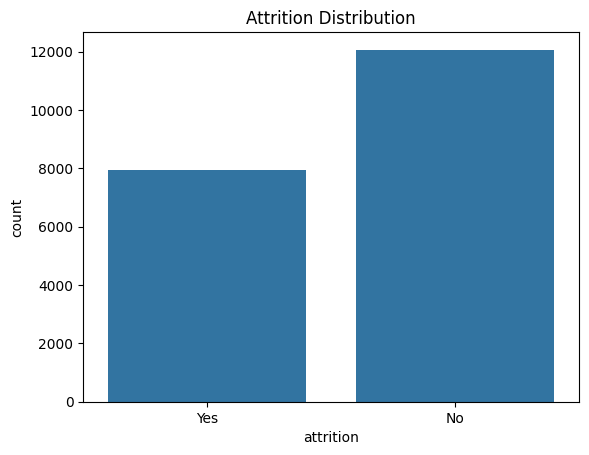

In [95]:
# Step 3: EDA

# Attrition Distribution
print(df['attrition'].value_counts())

sns.countplot(x='attrition', data=df)
plt.title("Attrition Distribution")
plt.show()

In [96]:
# Attrition Rate
attrition_rate = df['attrition'].value_counts(normalize=True)
print(attrition_rate)

attrition
No     0.60335
Yes    0.39665
Name: proportion, dtype: float64


# Insight:
# Around 39.6% of employees have left the company.
# This indicates a moderately high attrition rate.

attrition                     No       Yes
department                                
Finance                 0.615385  0.384615
Human Resources         0.591912  0.408088
Marketing               0.585721  0.414279
Operations              0.599204  0.400796
Research & Development  0.609113  0.390887
Sales                   0.601891  0.398109


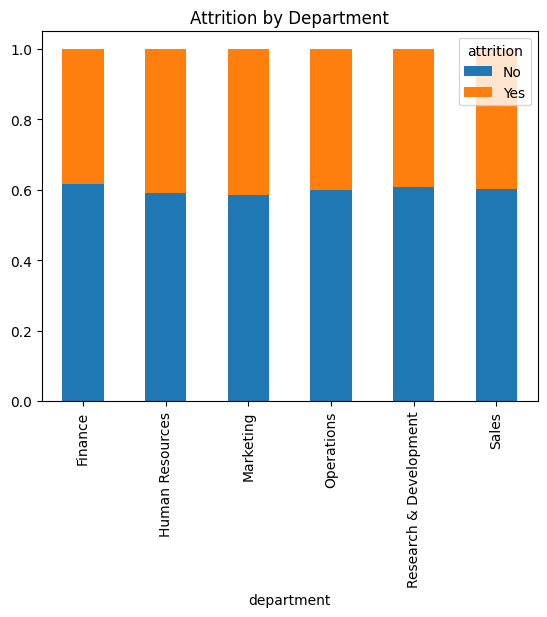

In [97]:
# Department wise attrition

dept_attrition = df.groupby('department')['attrition'].value_counts(normalize=True).unstack()

print(dept_attrition)

dept_attrition.plot(kind='bar', stacked=True)
plt.title("Attrition by Department")
plt.show()

# Insight:
# Marketing and HR departments have slightly higher attrition rates.
# Finance has the lowest attrition.
# This suggests department-specific factors influence employee turnover.

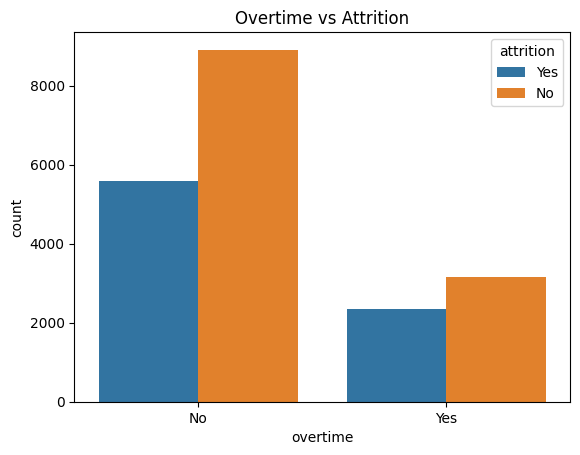

In [98]:
# Overtime vs Attrition

sns.countplot(x='overtime', hue='attrition', data=df)
plt.title("Overtime vs Attrition")
plt.show()

# Insight:
# Employees who work overtime are more likely to leave the company.
# This indicates work-life balance is a key factor in attrition.

# Overall EDA Conclusion:
# - The attrition rate is around 40%, which is significant.
# - Certain departments like Marketing and HR have higher attrition.
# - Overtime is strongly associated with higher attrition.
# - Work-life balance and job conditions likely influence employee retention.

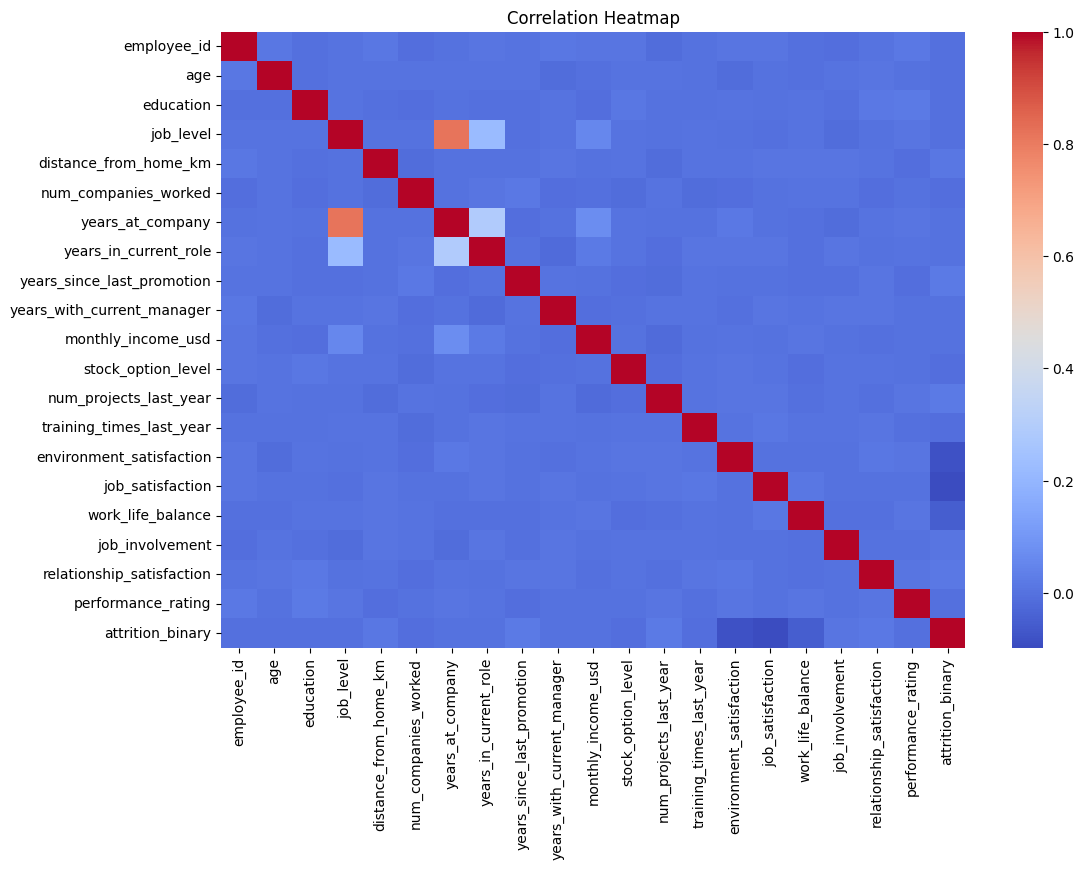

In [99]:
# Convert attrition to numeric
df['attrition_binary'] = df['attrition'].map({'Yes': 1, 'No': 0})

# Correlation
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# Insight:
# Most features show weak correlation with attrition,
# indicating attrition depends on multiple combined factors.
# However, satisfaction-related features (job, environment, work-life balance)
# show noticeable negative correlation with attrition.

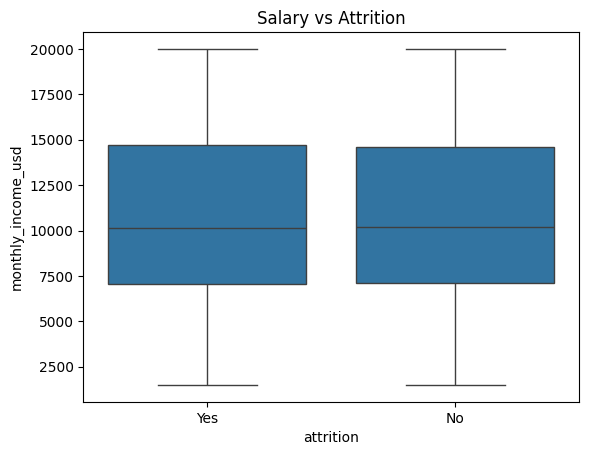

In [100]:
# Salary vs Attrition
sns.boxplot(x='attrition', y='monthly_income_usd', data=df)
plt.title("Salary vs Attrition")
plt.show()

# Insight:
# Monthly income does not show a strong difference between employees who left and stayed.
# Salary alone is not a major factor influencing attrition.

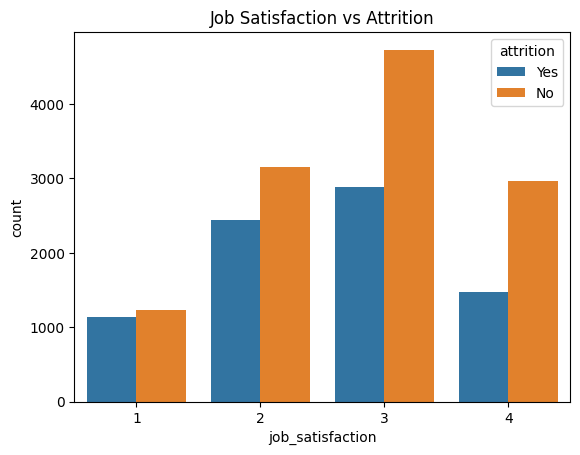

In [101]:
# Job Satisfaction
sns.countplot(x='job_satisfaction', hue='attrition', data=df)
plt.title("Job Satisfaction vs Attrition")
plt.show()

# Insight:
# Employees with lower job satisfaction are more likely to leave.
# Higher job satisfaction significantly reduces attrition.

# Final EDA Summary:
# - Attrition rate is around 40%, indicating a significant business problem.
# - Overtime is strongly associated with higher attrition.
# - Job satisfaction, environment satisfaction, and work-life balance
#   are key drivers of attrition.
# - Salary does not significantly impact attrition.
# - Attrition is influenced by multiple factors rather than a single variable.

# STEP 4: CLUSTERING (K-Means)

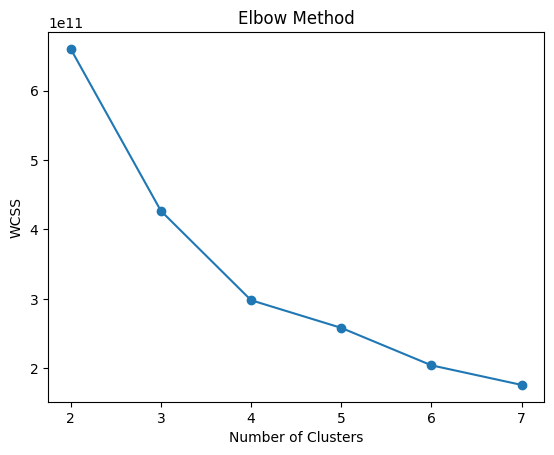

Silhouette Score: 0.414148050602058


In [102]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Use numeric data only
X_cluster = df.select_dtypes(include=['int64'])

# Elbow Method
wcss = []
for i in range(2, 8):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_cluster)
    wcss.append(kmeans.inertia_)

plt.plot(range(2, 8), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

# Final model
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_cluster)

df['cluster'] = clusters

# Silhouette Score
score = silhouette_score(X_cluster, clusters)
print("Silhouette Score:", score)

## Clustering Insight:
Employees are grouped into different clusters based on their characteristics.
These clusters can help identify high-risk employee segments.

In [103]:
# Step 5: Preprocessing


# Drop unnecessary columns
df_model = df.drop(['employee_id', 'join_date', 'attrition_binary'], axis=1)

# Separate X and y
X = df_model.drop('attrition', axis=1)
y = df_model['attrition']

# Identify columns
num_cols = X.select_dtypes(include=['int64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

# ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first'), cat_cols)
    ]
)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Fit and transform
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (16000, 50)
X_test shape: (4000, 50)


# Conclusion:
# The dataset was successfully preprocessed.
# Numerical features were scaled and categorical features were encoded.
# Data was split into training (80%) and testing (20%) sets.
# The final feature set contains 50 columns after encoding.

In [104]:
# Step 6: Model Building
# Classification - Logistic Regression

# Model
model = LogisticRegression(max_iter=1000, class_weight='balanced')

# Train
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:,1]

# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, pos_label='Yes'))
print("Recall:", recall_score(y_test, y_pred, pos_label='Yes'))
print("F1 Score:", f1_score(y_test, y_pred, pos_label='Yes'))
print("ROC-AUC:", roc_auc_score((y_test=='Yes').astype(int), y_pred_proba))

Accuracy: 0.573
Precision: 0.46699399890889254
Recall: 0.5393824826717076
F1 Score: 0.5005847953216375
ROC-AUC: 0.5916701462958858


# Logistic Regression Insight:
# The model achieved moderate performance with an F1 score of ~0.50 and ROC-AUC of ~0.59.
# Recall is slightly higher than precision, indicating the model is better at identifying
# employees who are likely to leave.
# However, overall performance suggests that more complex models may improve results.

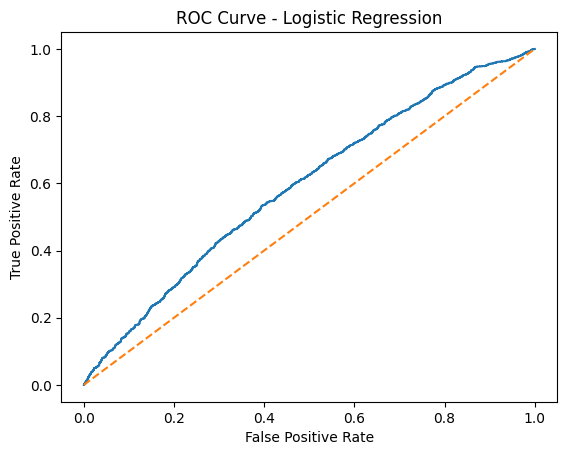

In [105]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve((y_test=='Yes').astype(int), y_pred_proba)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')
plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

In [106]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1_macro')
print("Cross-validation F1 scores:", cv_scores)
print("Mean CV Score:", cv_scores.mean())

Cross-validation F1 scores: [0.57788533 0.55557519 0.54384956 0.55709784 0.54935978]
Mean CV Score: 0.5567535407448487


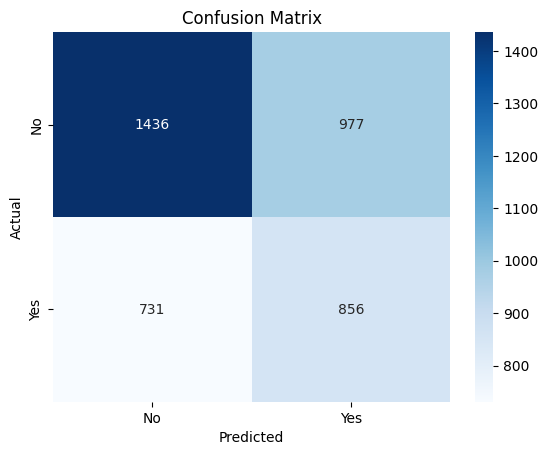

In [107]:
# STEP 7: CONFUSION MATRIX

cm = confusion_matrix(y_test, y_pred, labels=['No','Yes'])

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No','Yes'],
            yticklabels=['No','Yes'])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Confusion Matrix Insight:
# The model correctly identifies 856 employees who are likely to leave (True Positives).
# However, it misses 731 employees who actually left (False Negatives),
# which is critical in a business context.
# Reducing false negatives is important to improve employee retention strategies.

In [108]:
# STEP 8: RANDOM FOREST

# Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')

# Train
rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:,1]

# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, pos_label='Yes'))
print("Recall:", recall_score(y_test, y_pred_rf, pos_label='Yes'))
print("F1 Score:", f1_score(y_test, y_pred_rf, pos_label='Yes'))
print("ROC-AUC:", roc_auc_score((y_test=='Yes').astype(int), y_pred_proba_rf))

Accuracy: 0.59675
Precision: 0.45323741007194246
Recall: 0.07939508506616257
F1 Score: 0.13512064343163538
ROC-AUC: 0.5606265003860887


# Random Forest Insight:
# The Random Forest model shows slightly higher accuracy but extremely low recall.
# This indicates that the model is biased towards predicting the majority class (No),
# and fails to correctly identify employees who are likely to leave.
# Therefore, Logistic Regression performs better for this problem.

In [109]:
# STEP 9: Improved Random Forest

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    class_weight='balanced',
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, pos_label='Yes'))
print("Recall:", recall_score(y_test, y_pred_rf, pos_label='Yes'))
print("F1 Score:", f1_score(y_test, y_pred_rf, pos_label='Yes'))
print("ROC-AUC:", roc_auc_score((y_test=='Yes').astype(int), y_pred_proba_rf))

Accuracy: 0.58375
Precision: 0.4746753246753247
Recall: 0.46061751732829237
F1 Score: 0.467540773904701
ROC-AUC: 0.5890486080046878


# Model Comparison Insight:
# Logistic Regression performs better than Random Forest in terms of recall and F1-score.
# Since the goal is to identify employees likely to leave, recall is more important.
# Therefore, Logistic Regression is selected as the final model.

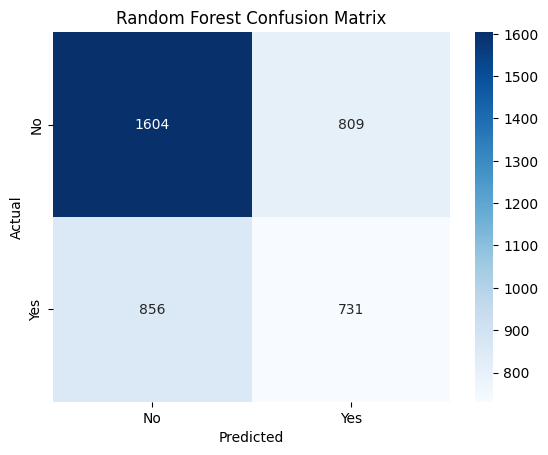

In [110]:
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=['No','Yes'])

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No','Yes'],
            yticklabels=['No','Yes'])

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [111]:
# STEP 10: FEATURE IMPORTANCE

# Feature Importance (Logistic Regression)

# Get feature names
feature_names = preprocessor.get_feature_names_out()

# Get coefficients
coefficients = model.coef_[0]

# Create dataframe
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': coefficients
})

# Sort
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# Top 10 features
print(feature_importance.head(10))

                                   Feature  Importance
47  cat__business_travel_Travel_Frequently    0.267564
49                       cat__overtime_Yes    0.228393
46                cat__job_role_Specialist    0.127742
48      cat__business_travel_Travel_Rarely    0.122434
37           cat__job_role_Human Resources    0.054227
7          num__years_since_last_promotion    0.048858
45      cat__job_role_Sales Representative    0.047062
11             num__num_projects_last_year    0.046181
20             cat__marital_status_Married    0.044764
42  cat__job_role_Marketing Representative    0.039396


# Business Insights:
# - Employees who travel frequently are more likely to leave the company.
# - Overtime is a strong factor contributing to attrition.
# - Lack of promotions increases the likelihood of employees leaving.
# - Employees handling more projects tend to experience higher stress and attrition.
# - Certain job roles have higher attrition rates, indicating role-specific challenges.

# Recommendations:
# - Reduce excessive business travel or provide travel compensation.
# - Limit overtime and improve work-life balance.
# - Ensure timely promotions and career growth opportunities.
# - Balance workload across employees.
# - Provide targeted retention strategies for high-risk job roles.

# Final Conclusion

This project aimed to predict employee attrition using machine learning models.

Logistic Regression performed better than Random Forest, especially in terms of recall and F1-score.

Key factors influencing attrition include overtime, frequent business travel, lack of promotions, and workload.

The model can help organizations identify at-risk employees and take proactive measures to improve retention.